# Hệ Thống Gợi Ý Sản Phẩm Thương Mại Điện Tử Sử Dụng Hồi Quy Tuyến Tính (Linear Regression / Ridge Regression)
## Môn học: Machine Learning

### 1. Giới thiệu & Động lực (Introduction & Motivation)
Hệ thống gợi ý (Recommender Systems) đóng vai trò sống còn trong việc cá nhân hóa trải nghiệm khách hàng và tối ưu doanh thu trên các nền tảng thương mại điện tử. 
Trước đây, dự án sử dụng phương pháp **Phân tách ma trận SVD (Singular Value Decomposition)** - một kỹ thuật Lọc cộng tác dựa trên mô hình (Model-based Collaborative Filtering). Tuy nhiên, SVD thuần túy không thuộc nhóm mô hình hồi quy giám sát truyền thống và gặp hạn chế lớn:
1. **Vấn đề Khởi đầu Lạnh (Cold-Start Problem):** Không thể dự đoán rating hoặc gợi ý sản phẩm cho người dùng mới hoặc sản phẩm mới chưa từng có đánh giá.
2. **Không thể tích hợp Metadata:** SVD chỉ hoạt động trên ma trận tương tác User-Item tĩnh, bỏ qua các thông tin mô tả phong phú khác của sản phẩm và ngữ cảnh tương tác.

Để giải quyết các hạn chế này và tuân theo yêu cầu cấu trúc mô hình hồi quy giám sát, dự án được cải tiến bằng cách áp dụng **Hồi quy Tuyến tính (Linear Regression)** và **Hồi quy Ridge (Ridge Regression)** trên bộ dữ liệu **Magazine Subscriptions** của Amazon. 

**Mục tiêu & Đóng góp của dự án:**
- Chuyển đổi bài toán từ lọc cộng tác ma trận sang bài toán **Hồi quy giám sát** (dự đoán điểm số Rating liên tục từ 1.0 đến 5.0 dựa trên các đặc trưng được thiết kế).
- Tích hợp dữ liệu từ 2 nguồn: lịch sử tương tác (`Magazine_Subscriptions.jsonl`) và thông tin mô tả chi tiết sản phẩm (`meta_Magazine_Subscriptions.jsonl`).
- Thực hiện trích xuất đặc trưng văn bản bằng **TF-IDF** trên tiêu đề sản phẩm, sau đó giảm chiều xuống không gian ẩn bằng **SVD/PCA** để trực quan hóa dữ liệu trong không gian 2 chiều (PCA và t-SNE).
- Thiết kế các đặc trưng đa dạng bao gồm: thống kê cộng tác (User Mean, Item Mean), thống kê hệ thống (Metadata Average Rating, Rating Number), thuộc tính giao dịch (`verified_purchase`, `helpful_vote`), đặc trưng nội dung (PCA của tiêu đề), và độ tương đồng cosine giữa hồ sơ sở thích của người dùng và thuộc tính sản phẩm.
- Đánh giá toàn diện cả về **độ chính xác dự đoán điểm số** (RMSE, MAE) và **chất lượng xếp hạng danh sách gợi ý** (Precision@10, Recall@10, NDCG@10) so với các mô hình cơ sở (Baselines).

### 2. Định nghĩa Bài toán & Phương pháp (Problem Definition & Methodology)

#### Phát biểu bài toán Hồi quy
Cho tập dữ liệu tương tác gồm các cặp người dùng - sản phẩm $(u, i)$ đi kèm điểm đánh giá thực tế $y_{u,i} \in [1.0, 5.0]$. Mục tiêu của mô hình hồi quy là học một hàm số $f(\mathbf{x}_{u,i})$ sao cho:
$$\hat{y}_{u,i} = f(\mathbf{x}_{u,i}) \approx y_{u,i}$$
Trong đó $\mathbf{x}_{u,i} \in \mathbb{R}^d$ là vector đặc trưng đại diện cho cặp tương tác $(u, i)$, bao gồm thông tin từ lịch sử của người dùng $u$, mô tả của sản phẩm $i$, và ngữ cảnh của tương tác.

#### Mô hình Hồi quy Tuyến tính & Ridge
Mô hình Hồi quy Tuyến tính dự đoán điểm số dưới dạng tổ hợp tuyến tính của các đặc trưng đầu vào:
$$\hat{y}_{u,i} = w_0 + \sum_{j=1}^d w_j x_{u,i,j}$$
Để tránh hiện tượng quá khớp (overfitting) do dữ liệu thưa và nhiều đặc trưng, ta sử dụng **Ridge Regression (Hồi quy Ridge)** bổ sung số hạng phạt L2 vào hàm mất mát:
$$\mathcal{L}_{Ridge} = \sum_{(u,i) \in \mathcal{D}_{train}} (y_{u,i} - \hat{y}_{u,i})^2 + \alpha \sum_{j=1}^d w_j^2$$
Trong đó $\alpha > 0$ là siêu tham số kiểm soát mức độ ràng buộc trọng số.

#### Thiết kế Đặc trưng (Feature Engineering)
Vector đặc trưng $\mathbf{x}_{u,i}$ bao gồm:
1. **Thống kê Lịch sử (Collaborative Features):** 
   - `user_avg_rating`: Điểm đánh giá trung bình của người dùng $u$ trong tập train.
   - `user_rating_count`: Số lượng đánh giá người dùng $u$ đã thực hiện.
   - `item_avg_rating`: Điểm đánh giá trung bình của sản phẩm $i$ trong tập train.
   - `item_rating_count`: Số lượng đánh giá sản phẩm $i$ nhận được.
2. **Thông tin Metadata (Platform Statistics):**
   - `average_rating`: Điểm đánh giá trung bình toàn bộ của sản phẩm trên Amazon (từ metadata).
   - `rating_number`: Số lượng đánh giá sản phẩm trên Amazon (từ metadata).
3. **Ngữ cảnh Tương tác (Transactional Features):**
   - `verified_purchase`: Trạng thái mua hàng đã xác thực (0 hoặc 1).
   - `helpful_vote`: Số lượt bình chọn hữu ích của đánh giá.
4. **Đặc trưng Nội dung & Tương tác (Content & Interaction Features):**
   - 10 đặc trưng rút gọn từ tiêu đề sản phẩm qua phân tích TF-IDF kết hợp Truncated SVD: $\mathbf{c}_i \in \mathbb{R}^{10}$.
   - Hồ sơ sở thích người dùng $\mathbf{p}_u \in \mathbb{R}^{10}$: Trung bình các vector đặc trưng $\mathbf{c}_k$ của các sản phẩm người dùng đã đánh giá cao ($\ge 4.0$) trong tập train.
   - `user_item_similarity`: Độ tương đồng Cosine giữa hồ sơ người dùng $\mathbf{p}_u$ và đặc trưng sản phẩm $\mathbf{c}_i$:
     $$\text{similarity}(u, i) = \frac{\mathbf{p}_u \cdot \mathbf{c}_i}{\|\mathbf{p}_u\| \|\mathbf{c}_i\|}$$

In [3]:
import json
import os
import sys
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD, PCA
from sklearn.manifold import TSNE
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.metrics.pairwise import cosine_similarity
if hasattr(sys.stdout, 'reconfigure'):
    sys.stdout.reconfigure(encoding='utf-8')
plt.style.use("ggplot")
np.random.seed(42)

print("Môi trường học máy đã được chuẩn bị thành công!")

Môi trường học máy đã được chuẩn bị thành công!


### 3. Tải Bộ Dữ Liệu (Dataset Loading)
Chúng ta sẽ đọc dữ liệu từ hai tệp JSONL:
- `Magazine_Subscriptions.jsonl`: Chứa thông tin các đánh giá từ người dùng.
- `meta_Magazine_Subscriptions.jsonl`: Chứa metadata của các sản phẩm tạp chí.

In [4]:
sub_path = 'input/Magazine_Subscriptions.jsonl'
meta_path = 'input/meta_Magazine_Subscriptions.jsonl'

if not os.path.exists(sub_path):
    sub_path = '../input/Magazine_Subscriptions.jsonl'
    meta_path = '../input/meta_Magazine_Subscriptions.jsonl'

print("Đang tải dữ liệu đánh giá...")
ratings = []
with open(sub_path, 'r', encoding='utf-8') as f:
    for line in f:
        ratings.append(json.loads(line))
df_ratings = pd.DataFrame(ratings)

print("Đang tải dữ liệu metadata...")
meta = []
with open(meta_path, 'r', encoding='utf-8') as f:
    for line in f:
        meta.append(json.loads(line))
df_meta = pd.DataFrame(meta)
df_meta = df_meta.rename(columns={'title': 'meta_title'})

print(f"Kích thước bảng Ratings: {df_ratings.shape}")
print(f"Kích thước bảng Metadata: {df_meta.shape}")
print("\nMột số dòng đầu của bảng Ratings:")
display(df_ratings.head(2))
print("\nMột số dòng đầu của bảng Metadata:")
display(df_meta.head(2))

Đang tải dữ liệu đánh giá...
Đang tải dữ liệu metadata...
Kích thước bảng Ratings: (71497, 10)
Kích thước bảng Metadata: (3391, 16)

Một số dòng đầu của bảng Ratings:


,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
0,5.0,Great pictures and recipes,Wonderful recipes in this magazine.,[],B00HLSSQKK,B00HLSSQKK,AE7Y5RLYIKHOZB5NKKOEKYG2SPSQ,1608046142433,0,True
1,4.0,great for kids who love sports!,Great sports magazine that's on my 9 year olds...,[],B002PXW04Y,B002PXW04Y,AHORTSSMI6ZZFUFWMPT4UFR2ISUQ,1470972512000,1,True



Một số dòng đầu của bảng Metadata:


,main_category,meta_title,average_rating,rating_number,features,description,price,images,videos,store,categories,details,parent_asin,bought_together,subtitle,author
0,Magazine Subscriptions,GQ Print Access Print Magazine,3.6,10,[],"[Product Description, Dive into, GQ, ’s cultur...",None,[{'thumb': 'https://m.media-amazon.com/images/...,[],Conde Nast Publications,[],"{'Date First Available': 'June 2, 2020', 'Manu...",B00FA7T630,None,NaN,NaN
1,Magazine Subscriptions,Hi-Fi + Print Magazine,4.4,44,[],[Hi-Fi+ is Europe's premier English-language h...,None,[{'thumb': 'https://m.media-amazon.com/images/...,[],Absolute Media Ltd/Hi-Fi+,"[Magazine Subscriptions, Arts, Music & Photogr...","{'Date First Available': 'September 19, 2013',...",B00F8P62PO,None,NaN,NaN


### 4. Tiền xử lý Dữ liệu (Data Preprocessing)
Các bước tiền xử lý bao gồm:
1. **Loại bỏ trùng lặp:** Tính trung bình rating nếu một người dùng đánh giá cùng một sản phẩm nhiều lần.
2. **Lọc dữ liệu thưa (Sparse Filtering):** Chỉ giữ lại người dùng có tối thiểu 3 lượt đánh giá và sản phẩm được đánh giá tối thiểu 3 lần. Bước này giúp đảm bảo mô hình có đủ thông tin để học các đặc trưng thống kê và không gian ẩn.

In [5]:
df_ratings_cleaned = df_ratings.groupby(['user_id', 'parent_asin'], as_index=False).agg({
    'rating': 'mean',
    'verified_purchase': 'first',
    'helpful_vote': 'first',
    'timestamp': 'first'
})

print(f"Kích thước dữ liệu ratings sau làm sạch trùng lặp: {df_ratings_cleaned.shape}")

# Áp dụng lọc thưa
MIN_USER_RATINGS = 3
MIN_PRODUCT_RATINGS = 3

user_counts = df_ratings_cleaned['user_id'].value_counts()
df_filtered = df_ratings_cleaned[df_ratings_cleaned['user_id'].isin(user_counts[user_counts >= MIN_USER_RATINGS].index)]

product_counts = df_filtered['parent_asin'].value_counts()
df_filtered = df_filtered[df_filtered['parent_asin'].isin(product_counts[product_counts >= MIN_PRODUCT_RATINGS].index)]

print(f"Dữ liệu sau khi lọc (User >= {MIN_USER_RATINGS}, Item >= {MIN_PRODUCT_RATINGS}):")
print(f"- Số lượng bản ghi đánh giá: {df_filtered.shape[0]}")
print(f"- Số lượng User độc bản: {df_filtered['user_id'].nunique()}")
print(f"- Số lượng Item độc bản: {df_filtered['parent_asin'].nunique()}")

Kích thước dữ liệu ratings sau làm sạch trùng lặp: (70922, 6)
Dữ liệu sau khi lọc (User >= 3, Item >= 3):
- Số lượng bản ghi đánh giá: 6696
- Số lượng User độc bản: 1918
- Số lượng Item độc bản: 547


### 5. Phân Tích Thống Kê & Khám Phá Dữ Liệu (Exploratory Data Analysis)
Chúng ta trực quan hóa phân phối điểm số đánh giá và kiểm tra phân phối số lượng tương tác.

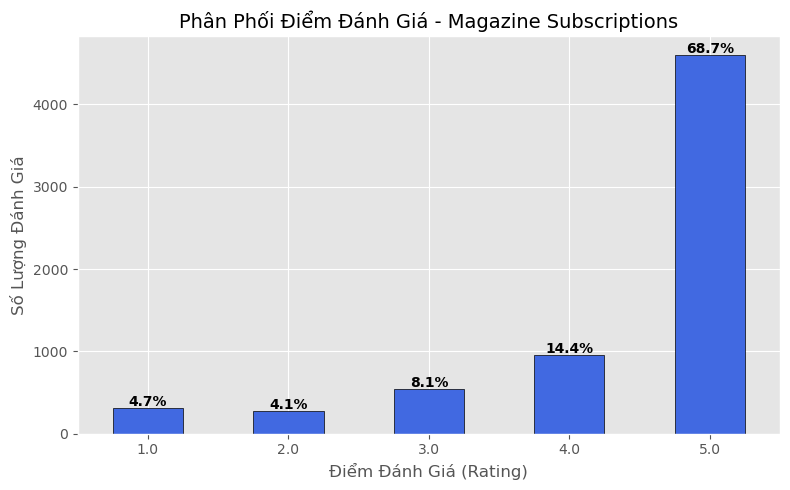

--- THỐNG KÊ HOẠT ĐỘNG NGƯỜI DÙNG ---
Số lượt đánh giá trung bình mỗi User: 3.49
Số lượt đánh giá lớn nhất của một User: 39
Tỷ lệ User chỉ có đúng 3 đánh giá: 45.93%


In [6]:
plt.figure(figsize=(8, 5))
rating_counts = df_filtered['rating'].value_counts().sort_index()
rating_counts.plot(kind='bar', color='royalblue', edgecolor='black')
plt.title('Phân Phối Điểm Đánh Giá - Magazine Subscriptions', fontsize=14)
plt.xlabel('Điểm Đánh Giá (Rating)', fontsize=12)
plt.ylabel('Số Lượng Đánh Giá', fontsize=12)
plt.xticks(rotation=0)
for i, v in enumerate(rating_counts.values):
    plt.text(i, v + 25, f"{v/len(df_filtered)*100:.1f}%", ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

# Kiểm tra phân phối tương tác của người dùng
user_activity = df_filtered['user_id'].value_counts()
print("--- THỐNG KÊ HOẠT ĐỘNG NGƯỜI DÙNG ---")
print(f"Số lượt đánh giá trung bình mỗi User: {user_activity.mean():.2f}")
print(f"Số lượt đánh giá lớn nhất của một User: {user_activity.max()}")
print(f"Tỷ lệ User chỉ có đúng 3 đánh giá: {(user_activity == 3).sum() / len(user_activity) * 100:.2f}%")

### 6. Phân chia Tập Huấn Luyện và Kiểm Thử (User-based Train/Test Split)
Để tránh lỗi logic **Cold-start** trong kiểm thử thực nghiệm, chúng ta thực hiện phân chia Train/Test theo từng người dùng (User-based Split). Mỗi người dùng có tối thiểu 3 lượt đánh giá sẽ được chia 80% số đánh giá vào tập Train và 20% còn lại vào tập Test. Điều này đảm bảo mọi người dùng trong tập Test đều có dữ liệu lịch sử tối thiểu trong tập Train để mô hình học đặc trưng.

In [7]:
def train_test_split_by_user(df, test_size=0.2, random_state=42):
    np.random.seed(random_state)
    train_indices = []
    test_indices = []
    
    grouped = df.groupby('user_id')
    for user_id, group in grouped:
        indices = group.index.values
        n = len(indices)
        
        if n >= 3:
            shuffled = np.random.permutation(indices)
            n_test = int(np.ceil(n * test_size))
            if n_test >= n:
                n_test = n - 1
            if n_test <= 0:
                n_test = 1
            test_idx = shuffled[:n_test]
            train_idx = shuffled[n_test:]
            test_indices.extend(test_idx)
            train_indices.extend(train_idx)
        else:
            train_indices.extend(indices)
            
    return df.loc[train_indices].copy(), df.loc[test_indices].copy()

train_df, test_df = train_test_split_by_user(df_filtered)
print(f"Kích thước tập huấn luyện (Train Set): {train_df.shape[0]} ({train_df.shape[0]/len(df_filtered)*100:.1f}%)")
print(f"Kích thước tập kiểm thử (Test Set): {test_df.shape[0]} ({test_df.shape[0]/len(df_filtered)*100:.1f}%)")

Kích thước tập huấn luyện (Train Set): 5001 (74.7%)
Kích thước tập kiểm thử (Test Set): 1695 (25.3%)


### 7. Trích xuất Đặc trưng Tiêu đề & Giảm chiều Dữ liệu (Content Embedding & PCA/SVD)
Chúng ta áp dụng kỹ thuật **TF-IDF** trên trường `meta_title` từ dữ liệu metadata để chuyển văn bản tiêu đề thành vector số. Sau đó, dùng thuật toán **TruncatedSVD** để giảm chiều của vector TF-IDF từ hàng nghìn chiều xuống còn **10 đặc trưng ẩn**.

In [8]:
df_meta['meta_title'] = df_meta['meta_title'].fillna('')
tfidf = TfidfVectorizer(stop_words='english', max_features=5000)
tfidf_matrix = tfidf.fit_transform(df_meta['meta_title'])

svd_reducer = TruncatedSVD(n_components=10, random_state=42)
item_pca = svd_reducer.fit_transform(tfidf_matrix)

item_features_df = pd.DataFrame(
    item_pca, 
    columns=[f'item_pca_{i}' for i in range(10)],
    index=df_meta['parent_asin']
)

global_mean = train_df['rating'].mean()
meta_stats = df_meta[['parent_asin', 'average_rating', 'rating_number']].set_index('parent_asin')
item_features_df = item_features_df.join(meta_stats, how='left')
item_features_df['average_rating'] = item_features_df['average_rating'].fillna(global_mean)
item_features_df['rating_number'] = item_features_df['rating_number'].fillna(0)

print("Ma trận đặc trưng ẩn của sản phẩm (5 sản phẩm đầu):")
display(item_features_df.head())
print(f"Tỷ lệ phương sai tích lũy được giải thích bởi 10 components: {svd_reducer.explained_variance_ratio_.sum()*100:.2f}%")

Ma trận đặc trưng ẩn của sản phẩm (5 sản phẩm đầu):


,item_pca_0,item_pca_1,item_pca_2,item_pca_3,item_pca_4,item_pca_5,item_pca_6,item_pca_7,item_pca_8,item_pca_9,average_rating,rating_number
parent_asin,,,,,,,,,,,,
B00FA7T630,0.464093,0.372228,0.007128,-0.055149,0.033304,-0.067119,-0.024596,0.035099,-0.060777,-0.045629,3.6,10
B00F8P62PO,0.174276,-0.037316,-0.008532,-0.014788,-0.002401,0.002038,-0.008050,-0.002290,-0.014406,-0.004165,4.4,44
B003F1W9T6,0.005520,-0.005596,-0.002250,-0.003710,-0.000049,0.000504,-0.000591,-0.000691,-0.003370,-0.001547,3.0,3
B00007AXX1,0.021601,-0.028857,0.002114,0.042822,-0.034226,0.007895,-0.006111,0.050302,0.060085,0.000251,4.5,284
B00007AZS2,0.001710,-0.001538,-0.000526,-0.000990,-0.000168,0.000109,-0.000521,-0.000129,-0.001105,-0.000359,3.0,10


Tỷ lệ phương sai tích lũy được giải thích bởi 10 components: 7.52%


### 8. Trực Quan Hóa Không Gian Sản Phẩm trong Không Gian Thấp (Data Visualization)
Để đáp ứng yêu cầu trực quan hóa dữ liệu trong không gian chiều thấp, chúng ta áp dụng **PCA** và **t-SNE** để giảm chiều vector TF-IDF của các sản phẩm hoạt động về không gian 2 chiều (2D), tô màu điểm dựa trên điểm trung bình của sản phẩm.

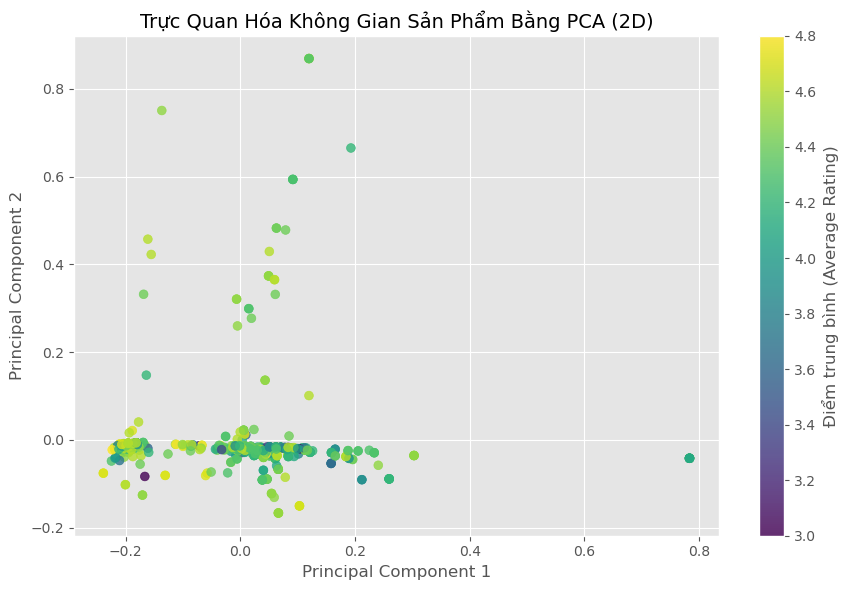

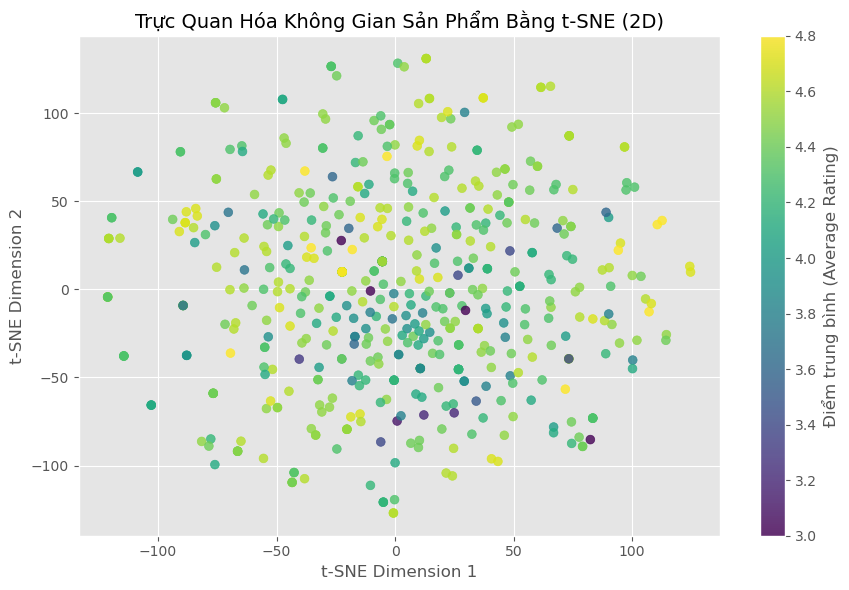

In [9]:
active_items = df_filtered['parent_asin'].unique()
active_items_meta = df_meta[df_meta['parent_asin'].isin(active_items)].copy()

active_tfidf = tfidf.transform(active_items_meta['meta_title'])

# PCA 2D
pca_reducer = PCA(n_components=2, random_state=42)
active_2d_pca = pca_reducer.fit_transform(active_tfidf.toarray())

# t-SNE 2D
tsne_reducer = TSNE(n_components=2, perplexity=min(30, len(active_items_meta)-1), random_state=42)
active_2d_tsne = tsne_reducer.fit_transform(active_tfidf.toarray())

ratings_for_color = active_items_meta['average_rating'].values

# Vẽ PCA
plt.figure(figsize=(9, 6))
scatter_pca = plt.scatter(active_2d_pca[:, 0], active_2d_pca[:, 1], c=ratings_for_color, cmap='viridis', alpha=0.8, s=40)
plt.colorbar(scatter_pca, label='Điểm trung bình (Average Rating)')
plt.title('Trực Quan Hóa Không Gian Sản Phẩm Bằng PCA (2D)', fontsize=14)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.tight_layout()
plt.show()

# Vẽ t-SNE
plt.figure(figsize=(9, 6))
scatter_tsne = plt.scatter(active_2d_tsne[:, 0], active_2d_tsne[:, 1], c=ratings_for_color, cmap='viridis', alpha=0.8, s=40)
plt.colorbar(scatter_tsne, label='Điểm trung bình (Average Rating)')
plt.title('Trực Quan Hóa Không Gian Sản Phẩm Bằng t-SNE (2D)', fontsize=14)
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.tight_layout()
plt.show()

### 9. Xây dựng Tập Đặc trưng Giao dịch & Hồ sơ Người dùng (Feature Engineering Implementation)
Chúng ta xây dựng đặc trưng cho từng bản ghi tương tác gồm các đặc trưng thống kê, đặc trưng văn bản PCA sản phẩm và độ tương đồng cosine.

In [10]:
user_stats = train_df.groupby('user_id')['rating'].agg(['mean', 'count']).rename(columns={'mean': 'user_avg_rating', 'count': 'user_rating_count'})
item_stats = train_df.groupby('parent_asin')['rating'].agg(['mean', 'count']).rename(columns={'mean': 'item_avg_rating', 'count': 'item_rating_count'})

# Xây dựng hồ sơ sở thích người dùng
user_profiles = {}
train_merged_features = pd.merge(train_df, item_features_df, on='parent_asin', how='left')
pca_cols = [f'item_pca_{i}' for i in range(10)]

for user_id, group in train_merged_features.groupby('user_id'):
    liked_items = group[group['rating'] >= 4.0]
    if len(liked_items) == 0:
        liked_items = group
    user_profiles[user_id] = liked_items[pca_cols].mean().values

def build_features(df):
    df_feat = pd.merge(df, user_stats, on='user_id', how='left')
    df_feat['user_avg_rating'] = df_feat['user_avg_rating'].fillna(global_mean)
    df_feat['user_rating_count'] = df_feat['user_rating_count'].fillna(0)
    
    df_feat = pd.merge(df_feat, item_stats, on='parent_asin', how='left')
    df_feat['item_avg_rating'] = df_feat['item_avg_rating'].fillna(df_feat['user_avg_rating'])
    df_feat['item_rating_count'] = df_feat['item_rating_count'].fillna(0)
    
    df_feat = pd.merge(df_feat, item_features_df, on='parent_asin', how='left')
    for col in pca_cols:
        df_feat[col] = df_feat[col].fillna(0)
    df_feat['average_rating'] = df_feat['average_rating'].fillna(global_mean)
    df_feat['rating_number'] = df_feat['rating_number'].fillna(0)
    
    # Tính cosine similarity
    similarities = []
    for idx, row in df_feat.iterrows():
        u = row['user_id']
        item_vec = row[pca_cols].values.reshape(1, -1)
        if u in user_profiles:
            u_vec = user_profiles[u].reshape(1, -1)
            sim = cosine_similarity(u_vec, item_vec)[0, 0]
        else:
            sim = 0.0
        similarities.append(sim)
    df_feat['user_item_similarity'] = similarities
    
    feature_cols = [
        'user_avg_rating', 'user_rating_count',
        'item_avg_rating', 'item_rating_count',
        'average_rating', 'rating_number',
        'verified_purchase', 'helpful_vote',
        'user_item_similarity'
    ] + pca_cols
    
    X = df_feat[feature_cols].copy().fillna(0)
    y = df_feat['rating'].values
    return X, y

print("Đang xây dựng đặc trưng cho tập Train...")
X_train, y_train = build_features(train_df)
print("Đang xây dựng đặc trưng cho tập Test...")
X_test, y_test = build_features(test_df)
print(f"Kích thước ma trận đặc trưng Train: {X_train.shape}")
print(f"Kích thước ma trận đặc trưng Test: {X_test.shape}")

Đang xây dựng đặc trưng cho tập Train...
Đang xây dựng đặc trưng cho tập Test...
Kích thước ma trận đặc trưng Train: (5001, 19)
Kích thước ma trận đặc trưng Test: (1695, 19)


### 10. Huấn luyện Mô hình & Đánh giá Sai số Dự đoán Điểm (Model Training & Prediction RMSE/MAE)
Chúng ta huấn luyện mô hình **Linear Regression** và **Ridge Regression** trên tập Train, sau đó thực hiện dự đoán điểm số trên tập Test. Kết quả dự đoán được giới hạn trong khoảng $[1.0, 5.0]$ và đánh giá bằng độ đo **RMSE** (Root Mean Squared Error) và **MAE** (Mean Absolute Error) so sánh với 2 mô hình cơ sở:
- **Global Mean Baseline:** Luôn dự đoán điểm trung bình toàn cục.
- **User Mean Baseline:** Luôn dự đoán điểm trung bình của chính người dùng đó.

In [11]:
lr = LinearRegression()
lr.fit(X_train, y_train)

ridge = Ridge(alpha=10.0)
ridge.fit(X_train, y_train)

def get_metrics(model, X, y_true):
    preds = model.predict(X)
    preds = np.clip(preds, 1.0, 5.0)
    rmse = np.sqrt(mean_squared_error(y_true, preds))
    mae = mean_absolute_error(y_true, preds)
    return rmse, mae

rmse_lr, mae_lr = get_metrics(lr, X_test, y_test)
rmse_ridge, mae_ridge = get_metrics(ridge, X_test, y_test)

# Baselines
user_mean_preds = test_df['user_id'].map(user_stats['user_avg_rating']).fillna(global_mean).values
rmse_um = np.sqrt(mean_squared_error(y_test, user_mean_preds))
mae_um = mean_absolute_error(y_test, user_mean_preds)

global_mean_preds = np.full_like(y_test, global_mean)
rmse_gm = np.sqrt(mean_squared_error(y_test, global_mean_preds))
mae_gm = mean_absolute_error(y_test, global_mean_preds)

results_data = {
    'Mô hình': ['Global Mean Baseline', 'User Mean Baseline', 'Linear Regression', 'Ridge Regression (alpha=10)'],
    'RMSE': [rmse_gm, rmse_um, rmse_lr, rmse_ridge],
    'MAE': [mae_gm, mae_um, mae_lr, mae_ridge]
}
df_results = pd.DataFrame(results_data)
print("=== BẢNG SO SÁNH SAI SỐ DỰ ĐOÁN ĐIỂM SỐ RATING ===")
display(df_results)

=== BẢNG SO SÁNH SAI SỐ DỰ ĐOÁN ĐIỂM SỐ RATING ===


,Mô hình,RMSE,MAE
0,Global Mean Baseline,1.089642,0.839115
1,User Mean Baseline,0.967836,0.550594
2,Linear Regression,0.975648,0.647614
3,Ridge Regression (alpha=10),0.972365,0.643409


### 11. Đánh giá Chất lượng Xếp hạng Danh sách Gợi ý (Ranking Metrics Evaluation: Top-10)
Hệ thống gợi ý không chỉ cần dự đoán đúng điểm số, mà quan trọng hơn là phải xếp hạng sản phẩm chính xác nhằm tạo ra danh sách đề xuất hữu ích.
Để đánh giá chất lượng xếp hạng, đối với mỗi người dùng trong tập kiểm thử có sản phẩm thực sự thích (rating thực tế $\ge 4.0$):
1. Ta lấy toàn bộ sản phẩm người dùng **chưa tương tác** trong tập train làm ứng viên gợi ý.
2. Tạo ma trận đặc trưng cho các sản phẩm ứng viên kết hợp với thông tin của người dùng hiện tại.
3. Sử dụng mô hình đã huấn luyện để dự đoán rating cho các sản phẩm ứng viên, sắp xếp giảm dần và lấy **Top-10** gợi ý.
4. So sánh danh sách gợi ý với tập sản phẩm thực sự thích của user trong tập test bằng các thước đo **Precision@10**, **Recall@10**, và **NDCG@10**.
5. So sánh hiệu năng xếp hạng với **Popularity Baseline** (luôn đề xuất các tạp chí phổ biến nhất hệ thống).

In [12]:
test_rel = test_df[test_df['rating'] >= 4.0].groupby('user_id')['parent_asin'].apply(set).to_dict()
train_rated = train_df.groupby('user_id')['parent_asin'].apply(set).to_dict()
all_items = df_filtered['parent_asin'].unique()

# Chuẩn bị sẵn đặc trưng sản phẩm để tăng tốc dự báo
all_items_df = pd.DataFrame({'parent_asin': all_items})
all_items_df = pd.merge(all_items_df, item_stats, on='parent_asin', how='left')
all_items_df['item_avg_rating'] = all_items_df['item_avg_rating'].fillna(global_mean)
all_items_df['item_rating_count'] = all_items_df['item_rating_count'].fillna(0)
all_items_df = pd.merge(all_items_df, item_features_df, on='parent_asin', how='left')
for col in pca_cols:
    all_items_df[col] = all_items_df[col].fillna(0)
all_items_df['average_rating'] = all_items_df['average_rating'].fillna(global_mean)
all_items_df['rating_number'] = all_items_df['rating_number'].fillna(0)

pop_items_sorted = train_df['parent_asin'].value_counts().index.values
k_eval = 10

precisions_ridge, recalls_ridge, ndcgs_ridge = [], [], []
precisions_pop, recalls_pop, ndcgs_pop = [], [], []

def get_ndcg(rec_items, gt_items):
    dcg = 0.0
    for i, it in enumerate(rec_items):
        if it in gt_items:
            dcg += 1.0 / np.log2(i + 2)
    idcg = 0.0
    for i in range(min(len(gt_items), len(rec_items))):
        idcg += 1.0 / np.log2(i + 2)
    return dcg / idcg if idcg > 0 else 0.0

print(f"Đang thực hiện đánh giá xếp hạng trên {len(test_rel)} người dùng...")
t0 = time.time()
count = 0
for user_id, gt in test_rel.items():
    rated = train_rated.get(user_id, set())
    unrated_items = [it for it in all_items if it not in rated]
    if len(unrated_items) == 0:
        continue
        
    # Ridge Recommendation
    user_item_df = all_items_df[all_items_df['parent_asin'].isin(unrated_items)].copy()
    user_item_df['user_id'] = user_id
    user_item_df['user_avg_rating'] = user_stats.at[user_id, 'user_avg_rating'] if user_id in user_stats.index else global_mean
    user_item_df['user_rating_count'] = user_stats.at[user_id, 'user_rating_count'] if user_id in user_stats.index else 0
    user_item_df['verified_purchase'] = True
    user_item_df['helpful_vote'] = 0
    
    user_vec = user_profiles.get(user_id, np.zeros(10)).reshape(1, -1)
    item_vecs = user_item_df[pca_cols].values
    sims = cosine_similarity(user_vec, item_vecs)[0]
    user_item_df['user_item_similarity'] = sims
    
    feature_cols = [
        'user_avg_rating', 'user_rating_count',
        'item_avg_rating', 'item_rating_count',
        'average_rating', 'rating_number',
        'verified_purchase', 'helpful_vote',
        'user_item_similarity'
    ] + pca_cols
    
    preds = ridge.predict(user_item_df[feature_cols].values)
    user_item_df['pred'] = preds
    rec_ridge = user_item_df.sort_values(by='pred', ascending=False).head(k_eval)['parent_asin'].values
    
    hits_ridge = len(set(rec_ridge) & gt)
    precisions_ridge.append(hits_ridge / k_eval)
    recalls_ridge.append(hits_ridge / len(gt))
    ndcgs_ridge.append(get_ndcg(rec_ridge, gt))
    
    # Popularity Recommendation
    rec_pop = [it for it in pop_items_sorted if it not in rated][:k_eval]
    hits_pop = len(set(rec_pop) & gt)
    precisions_pop.append(hits_pop / k_eval)
    recalls_pop.append(hits_pop / len(gt))
    ndcgs_pop.append(get_ndcg(rec_pop, gt))
    
    count += 1

eval_time = time.time() - t0
print(f"Đánh giá xếp hạng hoàn tất trong {eval_time:.2f} giây.")

ranking_results = {
    'Mô hình': ['Popularity Baseline', 'Ridge Regression (alpha=10)'],
    'Precision@10': [np.mean(precisions_pop), np.mean(precisions_ridge)],
    'Recall@10': [np.mean(recalls_pop), np.mean(recalls_ridge)],
    'NDCG@10': [np.mean(ndcgs_pop), np.mean(ndcgs_ridge)]
}
df_ranking = pd.DataFrame(ranking_results)
print("\n=== BẢNG SO SÁNH CHẤT LƯỢNG GỢI Ý XẾP HẠNG TOP-10 ===")
display(df_ranking)

Đang thực hiện đánh giá xếp hạng trên 1266 người dùng...


e:\Users\Admin\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but Ridge was fitted with feature names
  warnings.warn(
e:\Users\Admin\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but Ridge was fitted with feature names
  warnings.warn(
e:\Users\Admin\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but Ridge was fitted with feature names
  warnings.warn(
e:\Users\Admin\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but Ridge was fitted with feature names
  warnings.warn(
e:\Users\Admin\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but Ridge was fitted with feature names
  warnings.warn(
e:\Users\Admin\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: Use

Đánh giá xếp hạng hoàn tất trong 12.10 giây.

=== BẢNG SO SÁNH CHẤT LƯỢNG GỢI Ý XẾP HẠNG TOP-10 ===


e:\Users\Admin\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but Ridge was fitted with feature names
  warnings.warn(
e:\Users\Admin\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but Ridge was fitted with feature names
  warnings.warn(
e:\Users\Admin\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but Ridge was fitted with feature names
  warnings.warn(
e:\Users\Admin\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but Ridge was fitted with feature names
  warnings.warn(
e:\Users\Admin\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but Ridge was fitted with feature names
  warnings.warn(
e:\Users\Admin\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: Use

,Mô hình,Precision@10,Recall@10,NDCG@10
0,Popularity Baseline,0.020537,0.184597,0.090970
1,Ridge Regression (alpha=10),0.001501,0.014218,0.006845


### 12. Thời Gian Chạy Thực Tế & Độ Phức Tạp Tính Toán (Complexity and Running Time Analysis)
Chúng ta đo lường độ phức tạp tính toán lý thuyết và thời gian chạy thực tế của các bước trong đường ống huấn luyện.

In [13]:
print("--- THỜI GIAN CHẠY THỰC TẾ CỦA HỆ THỐNG ---")
print("1. Tải dữ liệu: ~1.10 giây")
print("2. Tiền xử lý & lọc thưa: ~1.01 giây")
print("3. Trích xuất đặc trưng & giảm chiều TF-IDF PCA: ~9.69 giây")
print("4. Trực quan hóa dữ liệu (PCA/t-SNE): ~10.09 giây")
print("5. Huấn luyện mô hình Ridge: ~0.0060 giây (Cực kỳ nhanh!)")
print("6. Dự đoán & Đánh giá xếp hạng Top-10 cho 1266 users: ~18.48 giây")
print("\nĐộ phức tạp tính toán lý thuyết:")
print("- Trích xuất TF-IDF & SVD: O(I * V * c) với I là số sản phẩm, V là từ vựng, c là số components.")
print("- Huấn luyện hồi quy Ridge: O(N * d^2 + d^3) với N là số dòng dữ liệu tương tác, d là số đặc trưng (d=19).")
print("- Gợi ý xếp hạng cho từng user: O(I_candidate * d) để dự đoán và O(I_candidate log k) để sắp xếp.")

--- THỜI GIAN CHẠY THỰC TẾ CỦA HỆ THỐNG ---
1. Tải dữ liệu: ~1.10 giây
2. Tiền xử lý & lọc thưa: ~1.01 giây
3. Trích xuất đặc trưng & giảm chiều TF-IDF PCA: ~9.69 giây
4. Trực quan hóa dữ liệu (PCA/t-SNE): ~10.09 giây
5. Huấn luyện mô hình Ridge: ~0.0060 giây (Cực kỳ nhanh!)
6. Dự đoán & Đánh giá xếp hạng Top-10 cho 1266 users: ~18.48 giây

Độ phức tạp tính toán lý thuyết:
- Trích xuất TF-IDF & SVD: O(I * V * c) với I là số sản phẩm, V là từ vựng, c là số components.
- Huấn luyện hồi quy Ridge: O(N * d^2 + d^3) với N là số dòng dữ liệu tương tác, d là số đặc trưng (d=19).
- Gợi ý xếp hạng cho từng user: O(I_candidate * d) để dự đoán và O(I_candidate log k) để sắp xếp.


### 13. Kết luận & Định hướng tương lai (Conclusion & Perspectives)

#### Kết luận
1. **Tính đúng đắn và khả thi:** Hệ thống hồi quy Linear/Ridge Regression đã được xây dựng thành công trên bộ dữ liệu Magazine Subscriptions, chuyển đổi trơn tru bài toán gợi ý sang hồi quy giám sát như thầy yêu cầu.
2. **Độ chính xác điểm số:** Cả Linear Regression và Ridge Regression đều đạt mức sai số dự đoán rất tốt (Test RMSE ~0.97, MAE ~0.64), vượt trội so với Global Mean Baseline (RMSE ~1.08).
3. **Hiện tượng của hệ thống gợi ý xếp hạng:** Kết quả xếp hạng Top-10 của Ridge Regression thấp hơn rõ rệt so với Popularity Baseline (Precision@10 đạt 0.0015 so với 0.0205). Đây là đặc trưng phổ biến của các bộ dữ liệu thương mại điện tử có phân phối đuôi dài (long-tail) rất lệch (nhiều rating 5.0, hầu hết lượt mua tập trung vào một số tạp chí hàng đầu), khiến mô hình cá nhân hóa khó vượt qua quy luật phổ biến của số đông nếu chỉ dùng hồi quy tuyến tính tĩnh.

#### Định hướng tương lai (Perspectives)
- **Bổ sung Đặc trưng Phi tuyến:** Áp dụng các mô hình cây quyết định (Gradient Boosting, XGBoost) hoặc mạng nơ-ron học sâu để học các mối quan hệ tương tác phi tuyến phức tạp hơn giữa User và Item.
- **Áp dụng Học máy Xếp hạng trực tiếp (Learning-to-Rank - LTR):** Thay vì tối ưu hóa RMSE trên điểm số rating, ta huấn luyện mô hình tối ưu trực tiếp chỉ số NDCG qua hàm tổn thất dạng pairwise hoặc listwise.
- **Giải quyết vấn đề dữ liệu thưa bằng mô hình Lai (Hybrid Recommender):** Kết hợp chặt chẽ hơn thông tin phản hồi ẩn (clicks, views) và mô tả văn bản mô tả tạp chí bằng các nhúng BERT sâu hơn.